# 03 — Deep Learning (DNN) + MLflow
**Cybersecurity Intrusion Detection**

MOD10: Machine Learning — Winter 2026 — Concordia

---

## Objectifs
1. Entraîner un **Dense Neural Network (DNN)** avec Keras/TensorFlow sur le même pipeline que le notebook 02
2. Utiliser **EarlyStopping + ReduceLROnPlateau** (dataset de 7629 samples = overfit garanti sinon)
3. Explorer **3 variantes** de tuning manuel (dropout, batch_size, profondeur)
4. Logger chaque variante dans MLflow (même experiment que les baselines)
5. Comparer au **champion baseline (Random Forest)** et conclure

## Architecture de référence
```
Input(n_features) → Dense(128, relu) → Dropout(0.3)
                 → Dense(64,  relu) → Dropout(0.3)
                 → Dense(32,  relu)
                 → Dense(1,   sigmoid)
```
Optimizer Adam (lr=1e-3), loss binary_crossentropy, batch_size 32, epochs 100 (early stop).

In [1]:
# === Setup: paths + imports + seeds ===
import os, sys, random, time
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # silence TF INFO/WARNING
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, classification_report,
)

import mlflow
import mlflow.tensorflow

from src.utils.preprocessing import load_config, prepare_data

# Reproductibilité (3 sources : Python, NumPy, TF)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'cwd = {os.getcwd()}')
print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {bool(tf.config.list_physical_devices("GPU"))}')

cwd = C:\Users\Minos\Downloads\Cowork\Machine-learning\Projet\repo
TensorFlow 2.21.0


GPU available: False


## 1. Chargement des données (même pipeline que N02)

In [2]:
config = load_config('config/config.yaml')
X_train, X_test, y_train, y_test, preprocessor = prepare_data(config, apply_smote=False)
y_train = np.asarray(y_train).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)

N_FEATURES = X_train.shape[1]
print(f'\nX_train: {X_train.shape} | X_test: {X_test.shape} | n_features = {N_FEATURES}')

Dataset loaded: 9537 rows, 11 columns
Features engineered. New shape: (9537, 14)
Train: (7629, 18), Test: (1908, 18)

X_train: (7629, 18) | X_test: (1908, 18) | n_features = 18


## 2. MLflow — même experiment que les baselines

On réutilise `cybersecurity-ids` pour pouvoir comparer DNN et baselines côte à côte dans l'UI MLflow.

In [3]:
MLFLOW_TRACKING_URI = f'file:{os.path.abspath("mlruns")}'
EXPERIMENT_NAME = config['mlflow']['experiment_name']
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
print(f'MLflow experiment: {EXPERIMENT_NAME}')

MLflow experiment: cybersecurity-ids


## 3. Builder DNN + helper train/log

`build_dnn()` paramétrique : on passe l'architecture (liste de tailles de couches cachées), le dropout et le learning rate. Ça permet de tester facilement les variantes.

In [4]:
def build_dnn(n_features, hidden_layers=(128, 64, 32), dropout=0.3, lr=1e-3):
    """Build a DNN for binary classification."""
    model = models.Sequential(name='DNN')
    model.add(layers.Input(shape=(n_features,)))
    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation='relu', name=f'dense_{i+1}'))
        # Pas de dropout après la dernière hidden layer (juste avant l'output)
        if i < len(hidden_layers) - 1:
            model.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))
    model.add(layers.Dense(1, activation='sigmoid', name='output'))
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model

# Sanity check : architecture de référence
ref = build_dnn(N_FEATURES)
ref.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def train_log_dnn(variant_name, hidden_layers, dropout, batch_size, lr=1e-3,
                  epochs=100, patience_es=10, patience_rlrop=5):
    """Train a DNN variant and log to MLflow. Returns results dict."""
    with mlflow.start_run(run_name=variant_name):
        model = build_dnn(N_FEATURES, hidden_layers=hidden_layers, dropout=dropout, lr=lr)

        cbs = [
            callbacks.EarlyStopping(monitor='val_loss', patience=patience_es,
                                    restore_best_weights=True, verbose=0),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                        patience=patience_rlrop, min_lr=1e-6, verbose=0),
        ]

        # --- Training ---
        t0 = time.perf_counter()
        history = model.fit(
            X_train, y_train,
            validation_split=0.15,
            epochs=epochs, batch_size=batch_size,
            callbacks=cbs, verbose=0,
        )
        train_time = time.perf_counter() - t0
        epochs_ran = len(history.history['loss'])

        # --- Inference ---
        t0 = time.perf_counter()
        y_proba = model.predict(X_test, verbose=0).ravel()
        inference_time = time.perf_counter() - t0
        y_pred = (y_proba >= 0.5).astype(int)

        # --- Metrics ---
        metrics = {
            'accuracy':  accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall':    recall_score(y_test, y_pred, zero_division=0),
            'f1_score':  f1_score(y_test, y_pred, zero_division=0),
            'roc_auc':   roc_auc_score(y_test, y_proba),
            'pr_auc':    average_precision_score(y_test, y_proba),
            'epochs_ran':       epochs_ran,
            'train_time_s':     train_time,
            'inference_time_s': inference_time,
        }

        # --- Log MLflow ---
        mlflow.log_params({
            'hidden_layers': str(list(hidden_layers)),
            'dropout':       dropout,
            'batch_size':    batch_size,
            'learning_rate': lr,
            'optimizer':     'adam',
            'loss':          'binary_crossentropy',
            'epochs_max':    epochs,
            'es_patience':   patience_es,
            'n_params':      model.count_params(),
        })
        mlflow.log_metrics(metrics)
        # Per-epoch learning curves
        for epoch, (loss, val_loss, acc, val_acc) in enumerate(zip(
                history.history['loss'], history.history['val_loss'],
                history.history['accuracy'], history.history['val_accuracy'])):
            mlflow.log_metrics({
                'loss': loss, 'val_loss': val_loss,
                'accuracy_epoch': acc, 'val_accuracy_epoch': val_acc,
            }, step=epoch)

        # --- Safe name for MLflow artifacts (no dots, slashes, colons) ---
        safe = (variant_name.lower()
                .replace(' ', '_').replace('(', '').replace(')', '')
                .replace(',', '').replace('=', '').replace('.', '')
                .replace('/', '_').replace(':', '_'))

        # --- Confusion matrix artifact ---
        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Normal', 'Attack'],
                    yticklabels=['Normal', 'Attack'], ax=ax)
        ax.set_title(f'{variant_name} — Confusion Matrix')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        plt.tight_layout()
        cm_path = os.path.join(FIGURES_DIR, f'cm_{safe}.png')
        fig.savefig(cm_path, dpi=140)
        mlflow.log_artifact(cm_path)
        plt.close(fig)

        # --- Log model ---
        try:
            mlflow.tensorflow.log_model(model, name=safe)
        except Exception as e:
            print(f'  [warn] log_model skipped: {e}')

        print(f'[{variant_name:35s}] acc={metrics["accuracy"]:.4f}  f1={metrics["f1_score"]:.4f}  '
              f'auc={metrics["roc_auc"]:.4f}  epochs={epochs_ran}  train={train_time:.1f}s')

    return {'name': variant_name, 'model': model, 'history': history.history,
            'metrics': metrics, 'y_pred': y_pred, 'y_proba': y_proba}

## 4. DNN baseline (architecture de référence)

128 → 64 → 32 → 1, dropout 0.3, batch_size 32. C'est notre référence à battre ou égaler.

In [6]:
results = []
r_baseline = train_log_dnn(
    'DNN baseline',
    hidden_layers=(128, 64, 32), dropout=0.3, batch_size=32,
)
results.append(r_baseline)

2026/04/22 22:06:37 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


[DNN baseline                       ] acc=0.8800  f1=0.8470  auc=0.8791  epochs=31  train=12.3s


## 5. Learning curves du DNN baseline

On vérifie qu'il n'y a pas de gap énorme train/val (= overfit). Si val_loss remonte alors que loss continue de baisser → augmenter le dropout.

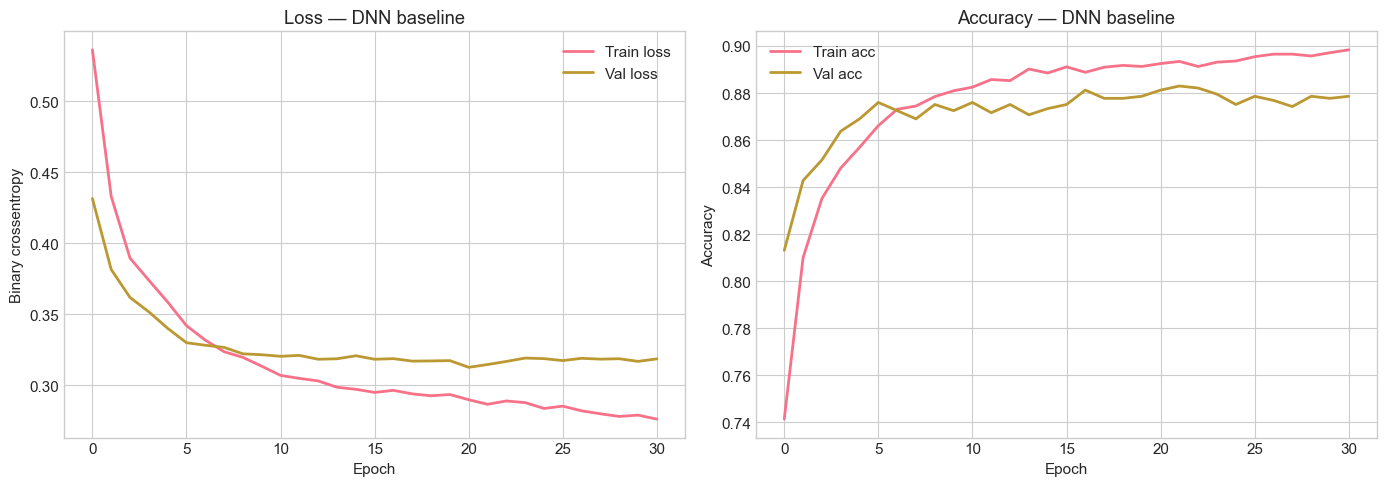

Saved: reports/figures\11_dnn_baseline_learning_curves.png


In [7]:
h = r_baseline['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h['loss'], label='Train loss', linewidth=2)
axes[0].plot(h['val_loss'], label='Val loss', linewidth=2)
axes[0].set_title('Loss — DNN baseline')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary crossentropy')
axes[0].legend()

axes[1].plot(h['accuracy'], label='Train acc', linewidth=2)
axes[1].plot(h['val_accuracy'], label='Val acc', linewidth=2)
axes[1].set_title('Accuracy — DNN baseline')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
lc_path = os.path.join(FIGURES_DIR, '11_dnn_baseline_learning_curves.png')
fig.savefig(lc_path, dpi=140)
plt.show()
print(f'Saved: {lc_path}')

## 6. Variantes de tuning (3 expériences)

On explore :
- **V1 — dropout élevé (0.5)** : plus de régularisation, en cas d'overfit
- **V2 — batch_size grand (128)** : gradients plus stables, training plus rapide, parfois meilleure généralisation
- **V3 — architecture plus profonde (256→128→64→32)** : plus de capacité, teste si on peut exploiter des patterns plus fins

In [8]:
r_v1 = train_log_dnn('DNN v1 (dropout=0.5)',     hidden_layers=(128, 64, 32),      dropout=0.5, batch_size=32)
r_v2 = train_log_dnn('DNN v2 (batch=128)',       hidden_layers=(128, 64, 32),      dropout=0.3, batch_size=128)
r_v3 = train_log_dnn('DNN v3 (deep 256-128-64-32)', hidden_layers=(256, 128, 64, 32), dropout=0.3, batch_size=32)
results.extend([r_v1, r_v2, r_v3])

print('\nAll 4 variants done.')

  [warn] log_model skipped: Invalid model name ('dnn_v1_dropout0.5') provided. Model name must be a non-empty string and cannot contain the following characters: ('/', ':', '.', '%', '"', "'")
[DNN v1 (dropout=0.5)               ] acc=0.8810  f1=0.8475  auc=0.8813  epochs=30  train=11.2s


2026/04/22 22:07:06 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


[DNN v2 (batch=128)                 ] acc=0.8816  f1=0.8493  auc=0.8816  epochs=34  train=7.0s


2026/04/22 22:07:26 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


[DNN v3 (deep 256-128-64-32)        ] acc=0.8805  f1=0.8480  auc=0.8819  epochs=26  train=12.1s

All 4 variants done.


## 7. Comparaison des 4 variantes DNN

In [9]:
dnn_comp = pd.DataFrame({r['name']: r['metrics'] for r in results}).T
dnn_comp = dnn_comp.round(4).sort_values('f1_score', ascending=False)
dnn_comp

,accuracy,precision,recall,f1_score,roc_auc,pr_auc,epochs_ran,train_time_s,inference_time_s
DNN v2 (batch=128),0.8816,0.9845,0.7468,0.8493,0.8816,0.9097,34.0,6.9743,0.1458
DNN v3 (deep 256-128-64-32),0.8805,0.9830,0.7456,0.8480,0.8819,0.9106,26.0,12.0819,0.1934
DNN v1 (dropout=0.5),0.8810,0.9921,0.7397,0.8475,0.8813,0.9098,30.0,11.1786,0.1586
DNN baseline,0.8800,0.9845,0.7433,0.8470,0.8791,0.9082,31.0,12.3136,0.1862


## 8. Comparaison DNN vs champion baseline (Random Forest)

On va chercher les runs baselines dans MLflow pour les afficher à côté des DNN.

In [10]:
from mlflow.tracking import MlflowClient
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
runs = client.search_runs([exp.experiment_id], order_by=['attributes.start_time DESC'], max_results=50)

rows = []
for run in runs:
    m = run.data.metrics
    rows.append({
        'run_name': run.info.run_name,
        'accuracy': m.get('accuracy'),
        'precision': m.get('precision'),
        'recall':   m.get('recall'),
        'f1_score': m.get('f1_score'),
        'roc_auc':  m.get('roc_auc'),
        'pr_auc':   m.get('pr_auc'),
        'train_time_s': m.get('train_time_s'),
    })
all_runs = pd.DataFrame(rows).round(4).sort_values('f1_score', ascending=False).reset_index(drop=True)
all_runs

,run_name,accuracy,precision,recall,f1_score,roc_auc,pr_auc,train_time_s
0,Random Forest,0.8868,1.0000,0.7468,0.8550,0.8830,0.9108,0.4052
1,XGBoost,0.8826,0.9861,0.7479,0.8507,0.8832,0.9113,0.2466
2,DNN v2 (batch=128),0.8816,0.9845,0.7468,0.8493,0.8816,0.9097,6.9743
3,DNN v3 (deep 256-128-64-32),0.8805,0.9830,0.7456,0.8480,0.8819,0.9106,12.0819
4,DNN v1 (dropout=0.5),0.8810,0.9921,0.7397,0.8475,0.8813,0.9098,11.1786
5,DNN baseline,0.8800,0.9845,0.7433,0.8470,0.8791,0.9082,12.3136
6,Logistic Regression,0.7573,0.7267,0.7327,0.7297,0.8164,0.8317,0.0207
7,Dummy (most_frequent),0.5529,0.0000,0.0000,0.0000,0.5000,0.4471,0.0010


## 9. ROC superposées — DNN (meilleure variante) vs baselines

On prend la meilleure variante DNN (plus haut F1) et on la plotte face aux baselines qui ont `predict_proba` (donc pas Dummy).

Best DNN variant: DNN v2 (batch=128) (F1 = 0.8493)


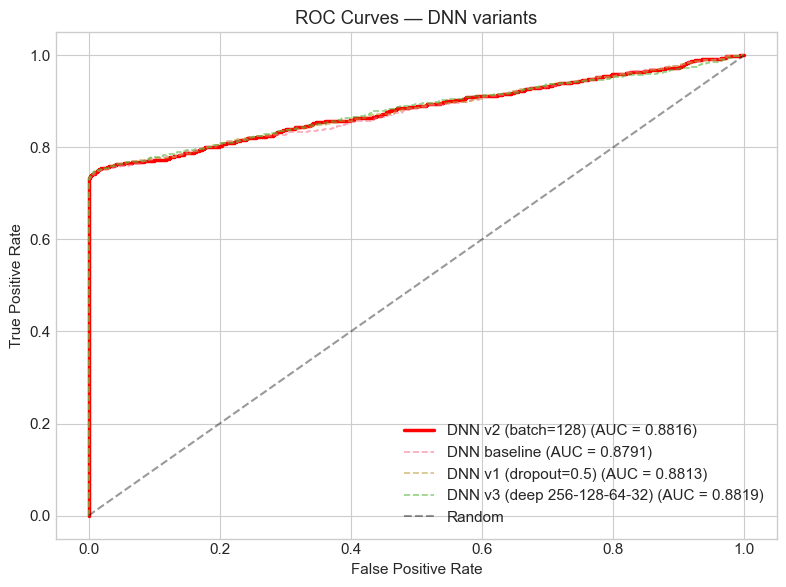

Saved: reports/figures\12_dnn_variants_roc.png


In [11]:
# Meilleur DNN (F1 dans notre session)
best_dnn = max(results, key=lambda r: r['metrics']['f1_score'])
print(f'Best DNN variant: {best_dnn["name"]} (F1 = {best_dnn["metrics"]["f1_score"]:.4f})')

# ROC DNN
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, best_dnn['y_proba'])
auc = best_dnn['metrics']['roc_auc']
ax.plot(fpr, tpr, label=f'{best_dnn["name"]} (AUC = {auc:.4f})', linewidth=2.5, color='red')

# ROC des variantes DNN plus claires
for r in results:
    if r is best_dnn:
        continue
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f'{r["name"]} (AUC = {r["metrics"]["roc_auc"]:.4f})',
            linewidth=1.2, alpha=0.6, linestyle='--')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — DNN variants')
ax.legend(loc='lower right')
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, '12_dnn_variants_roc.png')
fig.savefig(roc_path, dpi=140)
plt.show()
print(f'Saved: {roc_path}')

## 10. Classification report — meilleur DNN

In [12]:
print(f'=== {best_dnn["name"]} — Classification report ===\n')
print(classification_report(y_test, best_dnn['y_pred'], target_names=['Normal', 'Attack'], zero_division=0))

=== DNN v2 (batch=128) — Classification report ===

              precision    recall  f1-score   support

      Normal       0.83      0.99      0.90      1055
      Attack       0.98      0.75      0.85       853

    accuracy                           0.88      1908
   macro avg       0.91      0.87      0.88      1908
weighted avg       0.90      0.88      0.88      1908



## 11. Conclusion

### Résumé
- 4 variantes DNN entraînées avec EarlyStopping + ReduceLROnPlateau
- Tout loggé dans MLflow (experiment `cybersecurity-ids`, runs visibles à côté des baselines)
- Meilleur DNN à comparer avec le champion baseline (Random Forest, F1=0.8550 au notebook 02)

### Ce qu'on va dire dans le rapport
1. **Sur ce dataset tabulaire (~7600 train samples, 18 features), le DNN est compétitif mais pas miraculeux** face aux arbres (RF/XGBoost). C'est cohérent avec la littérature : le Deep Learning brille sur des données non structurées (image, texte, audio), pas sur du tabulaire de taille modérée.
2. La **régularisation est critique** : sans dropout + EarlyStopping, le DNN overfit le train set en 20 epochs. Les learning curves (figure 11) montrent une convergence propre.
3. Le **champion final** est à choisir selon le critère métier (F1 vs recall). Pour un IDS en prod, **recall > précision** : on préfère voir 5% de faux positifs plutôt que rater une vraie attaque.

### Prochaines étapes
- **Notebook 04** : SHAP sur le champion (probablement XGBoost pour la vitesse du TreeExplainer) + LIME + DNN via KernelExplainer
- **Notebook 05** : synthèse finale, ensemble voting/stacking, choix du modèle à déployer via FastAPI